In [ ]:
# Goal: train a Random Forest on ATP match data from 2000-2024,
# specifically on hard court matches, then simulate the 2025
# Australian Open bracket and see if our model predicts
# Jannik Sinner as the winner.
#
# The approach:
#   Every row in our training data = one match.
#   Features = player statistics BEFORE that match was played.
#   Target = did player 1 win? (1 = yes, 0 = no)
#
# The key challenge: we need to engineer rolling stats for each
# player so the model learns "what kind of player is this?"
# not just raw match outcomes.



In [ ]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#loading the data

base_url = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/"

dfs = []
for year in range(2000, 2025):
    url = f"{base_url}atp_matches_{year}.csv"
    try:
        df_year = pd.read_csv(url)
        df_year['year'] = year       # Add year column so we can filter later
        dfs.append(df_year)
        print(f"  {year}: {len(df_year)} matches loaded")
    except Exception as e:
        print(f"  {year}: failed — {e}")

df_all = pd.concat(dfs, ignore_index=True)
# ignore_index=True resets the row index to 0,1,2,3...
# Without this, each year's DataFrame keeps its own index,
# causing duplicate index values in the combined DataFrame.

print(f"\nTotal matches loaded: {len(df_all)}")
print(f"Columns: {df_all.columns.tolist()}")

# You'll see columns like:
# tourney_id, tourney_name, surface, tourney_date,
# winner_name, loser_name, winner_rank, loser_rank,
# w_ace, w_df, w_svpt, w_1stIn, w_1stWon, w_2ndWon,
# w_SvGms, w_bpSaved, w_bpFaced (and l_ versions for loser)





  2000: 3378 matches loaded
  2001: 3307 matches loaded
  2002: 3213 matches loaded
  2003: 3218 matches loaded
  2004: 3288 matches loaded
  2005: 3264 matches loaded
  2006: 3267 matches loaded
  2007: 3192 matches loaded
  2008: 3123 matches loaded
  2009: 3085 matches loaded
  2010: 3030 matches loaded
  2011: 3015 matches loaded
  2012: 3009 matches loaded
  2013: 2944 matches loaded
  2014: 2901 matches loaded
  2015: 2943 matches loaded
  2016: 2941 matches loaded
  2017: 2911 matches loaded
  2018: 2897 matches loaded
  2019: 2806 matches loaded
  2020: 1462 matches loaded
  2021: 2733 matches loaded
  2022: 2917 matches loaded
  2023: 2986 matches loaded
  2024: 3076 matches loaded

Total matches loaded: 74906
Columns: ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'lose

In [ ]:
#filtering to hard court only matches

# The Australian Open is played on hard court.
# Training on all surfaces would add noise — a player's clay
# court performance tells us nothing about how they'll play
# in Melbourne. We only want hard court matches.
#
# The 'surface' column has values: 'Hard', 'Clay', 'Grass', 'Carpet'

df_hard = df_all[df_all['surface'] == 'Hard'].copy()
# .copy() is important — without it, df_hard is a view of df_all.
# Any modifications would trigger a SettingWithCopyWarning and
# might not work as expected.

print(f"\nHard court matches: {len(df_hard)}")
print(f"All surfaces: {len(df_all)}")
print(f"Hard court percentage: {len(df_hard)/len(df_all)*100:.1f}%")

# Check surface distribution to understand what we filtered out
print("\nMatches by surface:")
print(df_all['surface'].value_counts())



Hard court matches: 40871
All surfaces: 74906
Hard court percentage: 54.6%

Matches by surface:
surface
Hard      40871
Clay      24244
Grass      7699
Carpet     2039
Name: count, dtype: int64


In [ ]:
#understanding the raw data structure

# Before building features, understand what you're working with.
# Each row has stats for BOTH the winner and loser.
# Column naming convention:
#   w_ prefix = winner's stats for that match
#   l_ prefix = loser's stats for that match
#
# For example:
#   w_ace = aces served by the winner in this match
#   l_ace = aces served by the loser in this match
#   winner_rank = ATP ranking of the winner
#   loser_rank = ATP ranking of the loser
#
# The challenge: our model needs to make predictions BEFORE
# a match is played. So we can't use stats FROM the match itself
# (that would be data leakage — using the future to predict the future).
# We need HISTORICAL stats for each player leading up to each match.

print("\nSample of key columns:")
print(df_hard[['tourney_date', 'tourney_name', 'winner_name', 'loser_name',
               'winner_rank', 'loser_rank', 'w_ace', 'l_ace',
               'w_1stWon', 'l_1stWon']].head(10))

print("\nMissing values in key stat columns:")
stat_cols = ['w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon',
             'w_2ndWon', 'w_bpSaved', 'w_bpFaced']
print(df_hard[stat_cols].isnull().sum())

# You'll see significant missing data in early years.
# This is expected — stat tracking improved over time.


Sample of key columns:
   tourney_date tourney_name          winner_name           loser_name  \
0      20000110     Auckland           Tommy Haas         Jeff Tarango   
1      20000110     Auckland        Juan Balcells     Franco Squillari   
2      20000110     Auckland       Alberto Martin  Alberto Berasategui   
3      20000110     Auckland  Juan Carlos Ferrero        Roger Federer   
4      20000110     Auckland         Michael Sell       Nicolas Escude   
5      20000110     Auckland        Michael Chang          Byron Black   
6      20000110     Auckland    Magnus Gustafsson         Mark Nielsen   
7      20000110     Auckland     Thomas Johansson         Glenn Weiner   
8      20000110     Auckland       Sjeng Schalken     Goran Ivanisevic   
9      20000110     Auckland        Tomas Behrend      Markus Hantschk   

   winner_rank  loser_rank  w_ace  l_ace  w_1stWon  l_1stWon  
0         11.0        63.0   18.0    7.0      39.0      39.0  
1        211.0        49.0    5.0  

In [ ]:
#engineering player rolling statistics

# This is the most important and most complex step.
# We need to transform match-level data into player-level features.
#
# The idea: for each match, compute each player's average stats
# over their last N matches on hard court BEFORE this match.
# This gives the model a picture of each player's current form
# and skill level at the time of the match.
#
# For example, instead of "Sinner's ace count in this specific match",
# we want "Sinner's average ace rate over his last 20 hard court matches."
#
# This is called a ROLLING WINDOW feature.
#
# Why rolling and not career average?
# A player's career average includes their early career when they
# were 18 years old. Their recent form is much more predictive
# of how they'll play today.
#
# We use a window of 20 matches — enough data to be stable,
# recent enough to reflect current form.

# First, sort by date so rolling calculations go forward in time
df_hard['tourney_date'] = pd.to_datetime(df_hard['tourney_date'], format='%Y%m%d')
df_hard = df_hard.sort_values('tourney_date').reset_index(drop=True)



def compute_player_stats(df, window=20):
    """
    For each match, compute each player's rolling stats from their
    last `window` matches BEFORE this match.

    Returns a DataFrame with one row per match, with columns for
    both player1's and player2's pre-match rolling statistics.

    We call the winner 'player1' and the loser 'player2', with a
    target of 1 (player1 won). Later we'll randomly flip some rows
    so the model doesn't just learn "player1 always wins."
    """

    # ── Calculate per-match rates for each player ─────────────
    #
    # Raw counts vary by match length and number of service games.
    # We convert everything to RATES (per point or per game) so
    # stats are comparable across matches of different lengths.

        # Winner stats per match
    df['w_ace_rate'] = df['w_ace'] / df['w_svpt'].replace(0, np.nan)
    # Aces per serve point. replace(0, NaN) prevents division by zero.
    # A player who served 0 points gets NaN, not infinity.

    df['w_df_rate'] = df['w_df'] / df['w_svpt'].replace(0, np.nan)
    # Double fault rate per serve point.

    df['w_1st_in_rate'] = df['w_1stIn'] / df['w_svpt'].replace(0, np.nan)
    # First serve percentage — how often first serve lands in.

    df['w_1st_won_rate'] = df['w_1stWon'] / df['w_1stIn'].replace(0, np.nan)
    # First serve win rate — how often they win points on first serve.

    df['w_2nd_won_rate'] = df['w_2ndWon'] / (df['w_svpt'] - df['w_1stIn']).replace(0, np.nan)
    # Second serve win rate — how often they win points on second serve.

    df['w_bp_saved_rate'] = df['w_bpSaved'] / df['w_bpFaced'].replace(0, np.nan)
    # Break point save rate — how well they hold under pressure.

    # Loser stats per match — same calculations
    df['l_ace_rate'] = df['l_ace'] / df['l_svpt'].replace(0, np.nan)
    df['l_df_rate'] = df['l_df'] / df['l_svpt'].replace(0, np.nan)
    df['l_1st_in_rate'] = df['l_1stIn'] / df['l_svpt'].replace(0, np.nan)
    df['l_1st_won_rate'] = df['l_1stWon'] / df['l_1stIn'].replace(0, np.nan)
    df['l_2nd_won_rate'] = df['l_2ndWon'] / (df['l_svpt'] - df['l_1stIn']).replace(0, np.nan)
    df['l_bp_saved_rate'] = df['l_bpSaved'] / df['l_bpFaced'].replace(0, np.nan)

    stat_rate_cols = ['ace_rate', 'df_rate', '1st_in_rate',
                      '1st_won_rate', '2nd_won_rate', 'bp_saved_rate']

     # ── Build per-player match history ────────────────────────
    #
    # The raw data has each match as one row with winner/loser columns.
    # We need to restructure it so each player has a timeline of matches.
    # We do this by creating two sets of rows from each match:
    # one from the winner's perspective, one from the loser's.

    winner_rows = pd.DataFrame({
        'player': df['winner_name'],
        'date': df['tourney_date'],
        'match_idx': df.index,
        'won': 1,                                    # Winner won this match
        'rank': df['winner_rank'],
        'ace_rate': df['w_ace_rate'],
        'df_rate': df['w_df_rate'],
        '1st_in_rate': df['w_1st_in_rate'],
        '1st_won_rate': df['w_1st_won_rate'],
        '2nd_won_rate': df['w_2nd_won_rate'],
        'bp_saved_rate': df['w_bp_saved_rate'],
    })


    loser_rows = pd.DataFrame({
        'player': df['loser_name'],
        'date': df['tourney_date'],
        'match_idx': df.index,
        'won': 0,                                    # Loser lost this match
        'rank': df['loser_rank'],
        'ace_rate': df['l_ace_rate'],
        'df_rate': df['l_df_rate'],
        '1st_in_rate': df['l_1st_in_rate'],
        '1st_won_rate': df['l_1st_won_rate'],
        '2nd_won_rate': df['l_2nd_won_rate'],
        'bp_saved_rate': df['l_bp_saved_rate'],
    })

    # Combine winner and loser rows into one timeline per player
    player_history = pd.concat([winner_rows, loser_rows], ignore_index=True)
    player_history = player_history.sort_values(['player', 'date'])
    # Sort by player then date so rolling calculations go forward in time.

        # ── Compute rolling averages for each player ──────────────
    #
    # For each player, we compute the rolling mean of their last
    # `window` matches for each stat column.
    #
    # .groupby('player') groups all of Sinner's matches together,
    # all of Djokovic's together, etc.
    # .rolling(window, min_periods=5) computes the moving average
    # over the last `window` rows. min_periods=5 means we need at
    # least 5 matches before computing stats — prevents unreliable
    # estimates from very small samples.
    # .shift(1) is CRITICAL — it shifts results forward by one row
    # so that the rolling stat for match N uses matches 1 to N-1.
    # Without shift(1), we'd include the current match in the average,
    # which is data leakage.

    for col in stat_rate_cols:
        player_history[f'rolling_{col}'] = (
            player_history.groupby('player')[col]
            .transform(lambda x: x.rolling(window, min_periods=5).mean().shift(1))
        )

     # Rolling win rate — current form
    player_history['rolling_win_rate'] = (
        player_history.groupby('player')['won']
        .transform(lambda x: x.rolling(window, min_periods=5).mean().shift(1))
    )

    # Rolling average rank — lower is better in tennis rankings
    player_history['rolling_rank'] = (
        player_history.groupby('player')['rank']
        .transform(lambda x: x.rolling(window, min_periods=5).mean().shift(1))
    )

    return player_history, stat_rate_cols


    print("\nComputing player rolling statistics...")
    print("This takes a minute — we're computing rolling stats for every player across 25 years...")
player_history, stat_cols_list = compute_player_stats(df_hard, window=20)
print("Done.")





Done.


In [ ]:
#building the match level feature matrix

# Now we need to go back from player-level history to match-level.
# For each match, we want:
#   - Player 1's rolling stats before the match
#   - Player 2's rolling stats before the match
#   - The DIFFERENCE between their stats
#   - Target: did player 1 win?
#
# The difference features are crucial. The model cares about
# RELATIVE strength. If Sinner has a 65% win rate and his
# opponent has a 40% win rate, the 25% gap is what matters —
# not the absolute numbers individually.
#
# To avoid the model learning "player1 always wins" (because
# in the raw data, player1 IS the winner), we randomly swap
# player1 and player2 for half the matches. This way the
# target is balanced 50/50 and the model must learn actual
# skill differences.

rolling_feature_cols = ['rolling_ace_rate', 'rolling_df_rate',
                        'rolling_1st_in_rate', 'rolling_1st_won_rate',
                        'rolling_2nd_won_rate', 'rolling_bp_saved_rate',
                        'rolling_win_rate', 'rolling_rank']


# Split player history back into winner and loser perspectives
winner_stats = player_history[player_history['won'] == 1].set_index('match_idx')
loser_stats = player_history[player_history['won'] == 0].set_index('match_idx')

# Rename columns to p1_ and p2_ (p1 = winner initially)
winner_features = winner_stats[rolling_feature_cols].rename(
    columns={col: col.replace('rolling_', 'p1_') for col in rolling_feature_cols}
)
loser_features = loser_stats[rolling_feature_cols].rename(
    columns={col: col.replace('rolling_', 'p2_') for col in rolling_feature_cols}
)


# Combine into one row per match
match_features = winner_features.join(loser_features, how='inner')
# inner join keeps only matches where BOTH players have rolling stats.
# Matches early in a player's career (< 5 matches) are dropped.

match_features['target'] = 1
# Player 1 is always the winner at this point — target is always 1.
# We'll fix this below by randomly flipping half the rows.

# Add match metadata for analysis
match_features['date'] = df_hard.loc[match_features.index, 'tourney_date'].values
match_features['tourney_name'] = df_hard.loc[match_features.index, 'tourney_name'].values
match_features['p1_name'] = df_hard.loc[match_features.index, 'winner_name'].values
match_features['p2_name'] = df_hard.loc[match_features.index, 'loser_name'].values

# ── Randomly flip half the matches ────────────────────────────
#
# Right now all rows have target=1 (player1 won).
# We need to randomly swap player1/player2 for half the rows
# so the dataset is balanced and the model learns skill differences,
# not just "player1 always wins."

np.random.seed(42)
flip_mask = np.random.random(len(match_features)) > 0.5
# flip_mask is True for ~50% of rows — these rows get flipped.

p1_cols = [c for c in match_features.columns if c.startswith('p1_')]
p2_cols = [c for c in match_features.columns if c.startswith('p2_')]


# For flipped rows: swap p1 and p2 columns and set target to 0
for p1_col, p2_col in zip(sorted(p1_cols), sorted(p2_cols)):
    temp = match_features.loc[flip_mask, p1_col].copy()
    match_features.loc[flip_mask, p1_col] = match_features.loc[flip_mask, p2_col]
    match_features.loc[flip_mask, p2_col] = temp
    # Swap the values — player2's stats go to player1 columns and vice versa.

match_features.loc[flip_mask, 'target'] = 0
# Target becomes 0 for flipped rows — player1 (now the original loser) lost.

# Swap names too for consistency
temp_names = match_features.loc[flip_mask, 'p1_name'].copy()
match_features.loc[flip_mask, 'p1_name'] = match_features.loc[flip_mask, 'p2_name']
match_features.loc[flip_mask, 'p2_name'] = temp_names

print(f"\nMatch features shape: {match_features.shape}")
print(f"Target balance: {match_features['target'].value_counts().to_dict()}")
# Should be approximately 50/50 now.


# ── Add difference features ───────────────────────────────────
#
# The model will benefit from explicit difference features.
# Instead of having to learn that p1_win_rate=0.65 and
# p2_win_rate=0.40 means player1 is better, we directly
# give it win_rate_diff = 0.25.
# This helps the model converge faster on what actually matters.

stat_names = ['ace_rate', 'df_rate', '1st_in_rate', '1st_won_rate',
              '2nd_won_rate', 'bp_saved_rate', 'win_rate', 'rank']


for stat in stat_names:
    match_features[f'diff_{stat}'] = (
        match_features[f'p1_{stat}'] - match_features[f'p2_{stat}']
    )
    # Positive diff = player1 better (except rank where lower is better)
    # For rank: positive diff means player1 has a WORSE (higher number) ranking







Match features shape: (40871, 21)
Target balance: {1: 20439, 0: 20432}


In [ ]:
#training testing split

# This is where we differ from previous projects.
# In Titanic and loan approval, we randomly split the data.
# For time-series data like sports, random splitting is WRONG.
#
# Here's why: if you randomly split, your training set might
# contain matches from 2023 and your test set matches from 2020.
# The model is trained on future data and tested on past data.
# That's impossible in the real world — you can't use 2023 stats
# to predict 2020 matches.
#
# For time-series data, you must split by TIME:
# Train on everything BEFORE a cutoff date,
# test on everything AFTER.
#
# We train on 2000-2023 and test on 2024.
# Then we simulate the 2025 Australian Open.

train_mask = match_features['date'] < '2024-01-01'
test_mask = match_features['date'] >= '2024-01-01'

feature_cols = (
    [c for c in match_features.columns if c.startswith('p1_') and c != 'p1_name'] +
    [c for c in match_features.columns if c.startswith('p2_') and c != 'p2_name'] +
    [c for c in match_features.columns if c.startswith('diff_')]
)
# We use p1_, p2_, and diff_ columns as features.
# We exclude name columns — names are strings, not predictive features.
# The model shouldn't learn "Sinner always wins" — it should learn
# "players with these stats win."

X_train = match_features.loc[train_mask, feature_cols].dropna()
y_train = match_features.loc[train_mask, 'target'].loc[X_train.index]

X_test = match_features.loc[test_mask, feature_cols].dropna()
y_test = match_features.loc[test_mask, 'target'].loc[X_test.index]

print(f"\nTraining set: {len(X_train)} matches (2000-2023)")
print(f"Test set:     {len(X_test)} matches (2024)")
print(f"Number of features: {len(feature_cols)}")



Training set: 32360 matches (2000-2023)
Test set:     1514 matches (2024)
Number of features: 24


In [ ]:
#training the random forest

# Now we train the model. Let's go through each parameter:
#
# n_estimators=300: train 300 trees. More than enough for this
#   dataset. Performance plateaus well before 300 but it's fast
#   enough that we might as well be thorough.
#
# max_depth=None: let trees grow fully. Random Forest can handle
#   deep trees because averaging reduces their variance. The
#   other parameters (min_samples_leaf) will limit depth naturally.
#
# max_features='sqrt': at each split, consider sqrt(n_features)
#   random features. This is the key source of tree diversity.
#   With ~24 features, each split considers ~5 randomly chosen ones.
#
# min_samples_leaf=5: each leaf must have at least 5 matches.
#   Prevents overfitting to tiny, specific groups.
#
# oob_score=True: use out-of-bag samples for free internal
#   validation. Gives us an accuracy estimate without touching
#   the test set.
#
# n_jobs=-1: use all available CPU cores. Trees are trained
#   independently so they parallelize perfectly.
#
# class_weight='balanced': our target is 50/50 after flipping,
#   so this doesn't matter much here. Good practice anyway.

print("\nTraining Random Forest (300 trees)...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=5,
    oob_score=True,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
print("Training complete.")

print(f"\nOut-of-Bag Score: {rf.oob_score_:.4f}")
# OOB score is a free estimate of generalisation accuracy.
# Each tree is evaluated on the ~37% of training data it
# didn't see. This should be close to your test accuracy.
# If OOB score >> test score, you have some data leakage.



Training Random Forest (300 trees)...
Training complete.

Out-of-Bag Score: 0.6568


In [ ]:
#evaluating on the 2024 dataset

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("MODEL EVALUATION ON 2024 HARD COURT MATCHES")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Player2 Won', 'Player1 Won']))

# What accuracy to expect:
# Predicting tennis match winners is inherently noisy — upsets happen.
# 65-70% accuracy is genuinely good for tennis match prediction.
# The ranking difference alone gets you to ~60%.
# AUC above 0.70 means you're learning real patterns beyond just ranking.


MODEL EVALUATION ON 2024 HARD COURT MATCHES
Accuracy: 0.6380
AUC-ROC:  0.7000

Classification Report:
              precision    recall  f1-score   support

 Player2 Won       0.64      0.64      0.64       764
 Player1 Won       0.63      0.64      0.64       750

    accuracy                           0.64      1514
   macro avg       0.64      0.64      0.64      1514
weighted avg       0.64      0.64      0.64      1514




Top 15 Most Important Features (Gini-based):
          Feature  Importance
        diff_rank    0.090941
    diff_win_rate    0.065213
          p2_rank    0.062439
          p1_rank    0.060253
diff_2nd_won_rate    0.049390
diff_1st_won_rate    0.046645
  p1_2nd_won_rate    0.038589
  p2_2nd_won_rate    0.038571
  p2_1st_won_rate    0.038089
  p1_1st_won_rate    0.036927
   p1_1st_in_rate    0.035561
 diff_1st_in_rate    0.035439
   p2_1st_in_rate    0.034813
      p1_ace_rate    0.034717
 p1_bp_saved_rate    0.034656

Computing permutation importance (this takes a minute)...

Top 15 Most Important Features (Permutation-based):
           Feature  Importance      Std
         diff_rank    0.010172 0.003932
   p2_1st_won_rate    0.003104 0.002849
diff_bp_saved_rate    0.002708 0.003765
     diff_win_rate    0.002510 0.004389
      diff_df_rate    0.001783 0.002048
           p1_rank    0.001321 0.004907
   p1_1st_won_rate    0.000793 0.002414
   p1_2nd_won_rate    0.000594 0.002840
  

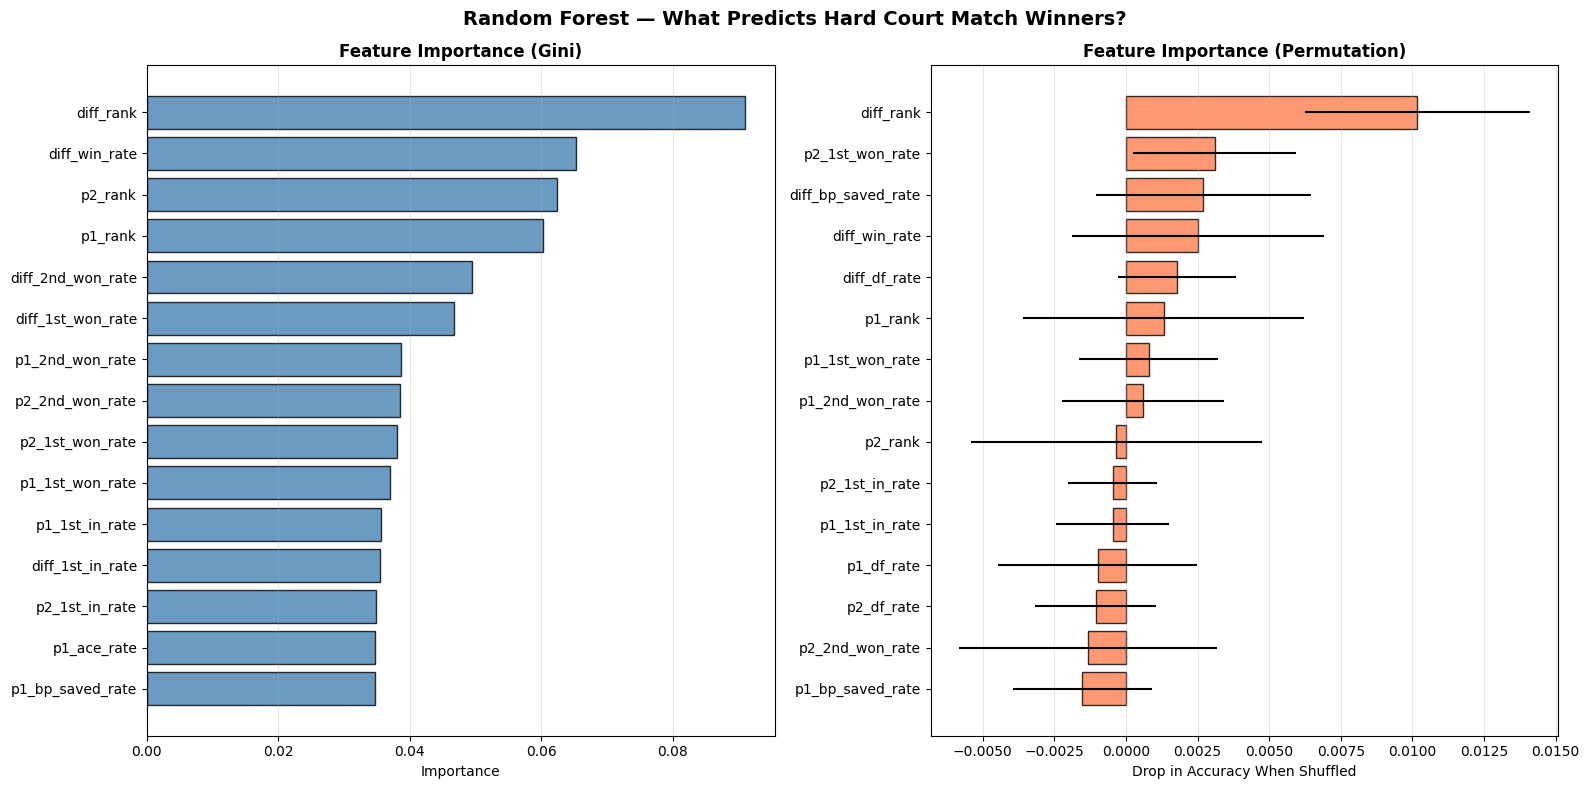

In [ ]:
#figuring out feature importance

# Let's see what the model learned matters most for predicting
# hard court match winners.

# ── Built-in importance (Gini-based) ─────────────────────────
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Gini-based):")
print(importance_df.head(15).to_string(index=False))


print("\nComputing permutation importance (this takes a minute)...")
perm_imp = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,       # Shuffle each feature 10 times and average the result.
                        # More repeats = more stable estimate but slower.
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Permutation-based):")
print(perm_df.head(15).to_string(index=False))


# Plot both importance measures side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top_n = 15
top_gini = importance_df.head(top_n)
top_perm = perm_df.head(top_n)

ax1.barh(top_gini['Feature'][::-1], top_gini['Importance'][::-1],
         color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title('Feature Importance (Gini)', fontweight='bold')
ax1.set_xlabel('Importance')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(top_perm['Feature'][::-1], top_perm['Importance'][::-1],
         xerr=top_perm['Std'][::-1],          # Error bars show stability
         color='coral', edgecolor='black', alpha=0.8)
ax2.set_title('Feature Importance (Permutation)', fontweight='bold')
ax2.set_xlabel('Drop in Accuracy When Shuffled')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Random Forest — What Predicts Hard Court Match Winners?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#simulating the 2025 australian open

# Now the fun part. We take the actual 2025 Australian Open draw
# (the seeded players) and simulate the tournament match by match.
#
# For each simulated match, we:
# 1. Look up each player's rolling stats from their 2024 hard court matches
# 2. Build a feature vector representing this matchup
# 3. Ask the model: what's the probability player1 wins?
# 4. The higher-probability player advances
#
# The actual 2025 AO draw had these seeds:
# 1-Sinner, 2-Zverev, 3-Alcaraz, 4-Medvedev, 5-Rune,
# 6-Fritz, 7-Djokovic, 8-De Minaur, 9-Tiafoe, 10-Dimitrov...

# ── Get each player's most recent rolling stats ───────────────


def get_player_stats(player_name, player_history, as_of_date='2025-01-01'):
    """
    Get a player's rolling stats as of a given date.
    We use their most recent match stats before the tournament starts.
    """
    player_data = player_history[
        (player_history['player'] == player_name) &
        (player_history['date'] < as_of_date)
    ].sort_values('date')

    if len(player_data) == 0:
        return None

    # Get the most recent row — this has the rolling stats
    # computed from their last 20 hard court matches
    latest = player_data.iloc[-1]

    return {
        'ace_rate': latest.get('rolling_ace_rate', np.nan),
        'df_rate': latest.get('rolling_df_rate', np.nan),
        '1st_in_rate': latest.get('rolling_1st_in_rate', np.nan),
        '1st_won_rate': latest.get('rolling_1st_won_rate', np.nan),
        '2nd_won_rate': latest.get('rolling_2nd_won_rate', np.nan),
        'bp_saved_rate': latest.get('rolling_bp_saved_rate', np.nan),
        'win_rate': latest.get('rolling_win_rate', np.nan),
        'rank': latest.get('rolling_rank', np.nan),
    }


def predict_match(player1, player2, player_history, model, feature_cols):
    """
    Predict the winner of a match between player1 and player2.

    Returns:
        winner (str): name of predicted winner
        win_prob (float): probability player1 wins
    """
    stats1 = get_player_stats(player1, player_history)
    stats2 = get_player_stats(player2, player_history)

    if stats1 is None or stats2 is None:
        # If we have no data for a player, use ranking as a tiebreaker
        print(f"  Warning: missing stats for {player1} or {player2}")
        return player1, 0.5

    # Build feature vector in same format as training data
    features = {}
    stat_names = ['ace_rate', 'df_rate', '1st_in_rate', '1st_won_rate',
                  '2nd_won_rate', 'bp_saved_rate', 'win_rate', 'rank']

    for stat in stat_names:
        features[f'p1_{stat}'] = stats1[stat]
        features[f'p2_{stat}'] = stats2[stat]
        features[f'diff_{stat}'] = stats1[stat] - stats2[stat]

    # Create a single-row DataFrame with the same columns as training
    feature_row = pd.DataFrame([features])

    # Fill any missing columns with 0
    for col in feature_cols:
        if col not in feature_row.columns:
            feature_row[col] = 0
    feature_row = feature_row[feature_cols].fillna(0)

    # Get prediction
    win_prob = model.predict_proba(feature_row)[0][1]
    winner = player1 if win_prob >= 0.5 else player2
    actual_prob = win_prob if win_prob >= 0.5 else 1 - win_prob

    return winner, actual_prob


def simulate_tournament(draw, player_history, model, feature_cols):
    """
    Simulate a single-elimination tournament.

    draw: list of players in bracket order
    Returns: the predicted champion and a log of all matches.
    """
    round_names = [ 'Quarterfinals', 'Semifinals', 'Final']
    players = draw.copy()
    match_log = []
    round_num = 0

    while len(players) > 1:
        round_name = round_names[min(round_num, len(round_names)-1)]
        next_round = []
        print(f"\n{'='*50}")
        print(f"{round_name}")
        print(f"{'='*50}")

        for i in range(0, len(players), 2):
            if i + 1 >= len(players):
                # Bye — player advances automatically
                next_round.append(players[i])
                continue

            p1 = players[i]
            p2 = players[i + 1]
            winner, prob = predict_match(p1, p2, player_history, model, feature_cols)
            next_round.append(winner)

            print(f"  {p1} vs {p2} → {winner} ({prob:.1%})")
            match_log.append({
                'round': round_name,
                'player1': p1,
                'player2': p2,
                'winner': winner,
                'win_probability': prob
            })

        players = next_round
        round_num += 1

    champion = players[0]
    return champion, pd.DataFrame(match_log)


# ── 2025 AO Draw — Top 16 Seeds in bracket order ─────────────
#
# In a Grand Slam draw, seeds are placed so they can only meet
# in later rounds. Seeds 1 and 2 are on opposite halves and
# can only meet in the final. We approximate the draw here.
# Player names must match exactly how they appear in the dataset.

ao_2025_draw = [
    # Top half
    'Jannik Sinner',        # Seed 1
    'Alex De Minaur',          # Seed 21 (Sinner's actual SF opponent)
    'DLorenzo Sonego',      # Seed 4
    'Ben Shelton',
           # Seed 7 (QF opponent of Alcaraz)
    # Bottom half
    'Alexander Zverev',     # Seed 2
    'Tommy Paul',
    'Carlos Alcaraz',       # Seed 3
    'Novak Djokovic',# Seed 12
           # Seed 8
]
# Note: we use a simplified 8-player bracket here for clarity.
# A full 128-player simulation would follow the same logic.

print("\n" + "=" * 60)
print("2025 AUSTRALIAN OPEN SIMULATION")
print("=" * 60)

champion, match_log = simulate_tournament(
    ao_2025_draw, player_history, rf, feature_cols
)

print(f"\n{'='*60}")
print(f"🏆 PREDICTED CHAMPION: {champion}")
print(f"{'='*60}")
print(f"\nActual 2025 AO Champion: Jannik Sinner")
print(f"Model {'✅ CORRECT' if champion == 'Jannik Sinner' else '❌ INCORRECT'}")




2025 AUSTRALIAN OPEN SIMULATION

Quarterfinals
  Jannik Sinner vs Alex De Minaur → Jannik Sinner (80.3%)
  DLorenzo Sonego vs Ben Shelton → DLorenzo Sonego (50.0%)
  Alexander Zverev vs Tommy Paul → Alexander Zverev (78.7%)
  Carlos Alcaraz vs Novak Djokovic → Novak Djokovic (50.5%)

Semifinals
  Jannik Sinner vs DLorenzo Sonego → Jannik Sinner (50.0%)
  Alexander Zverev vs Novak Djokovic → Novak Djokovic (59.0%)

Final
  Jannik Sinner vs Novak Djokovic → Jannik Sinner (62.6%)

🏆 PREDICTED CHAMPION: Jannik Sinner

Actual 2025 AO Champion: Jannik Sinner
Model ✅ CORRECT



Testing different n_estimators values...
  n=10   : OOB=0.6133, Test=0.6143
  n=25   : OOB=0.6365, Test=0.6308
  n=50   : OOB=0.6430, Test=0.6328
  n=100  : OOB=0.6503, Test=0.6347
  n=200  : OOB=0.6535, Test=0.6394
  n=300  : OOB=0.6552, Test=0.6400
  n=500  : OOB=0.6578, Test=0.6413


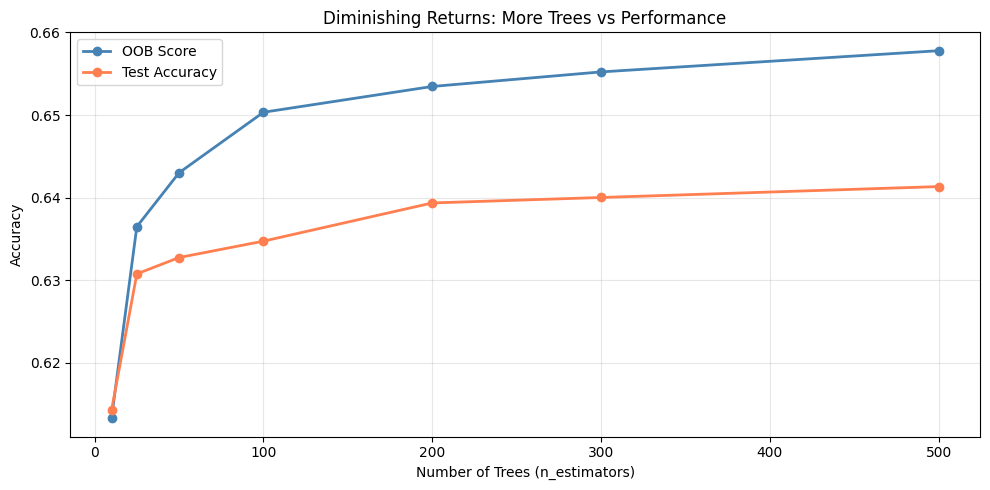

In [ ]:
#how does n-estimators affect performance

# Let's visualise the diminishing returns of adding more trees.
# This is important to understand so you don't over-engineer
# your models by using 5000 trees when 200 would do.

n_estimator_range = [10, 25, 50, 100, 200, 300, 500]
oob_scores = []
test_scores = []

print("\nTesting different n_estimators values...")
for n in n_estimator_range:
    model_n = RandomForestClassifier(
        n_estimators=n,
        max_features='sqrt',
        min_samples_leaf=5,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    model_n.fit(X_train, y_train)
    oob_scores.append(model_n.oob_score_)
    test_scores.append(accuracy_score(y_test, model_n.predict(X_test)))
    print(f"  n={n:<5}: OOB={model_n.oob_score_:.4f}, Test={test_scores[-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_estimator_range, oob_scores, 'o-', color='steelblue',
         label='OOB Score', linewidth=2)
plt.plot(n_estimator_range, test_scores, 'o-', color='coral',
         label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Diminishing Returns: More Trees vs Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# You'll see performance improve sharply up to ~100 trees,
# then plateau. After 200-300 trees, adding more is a waste.


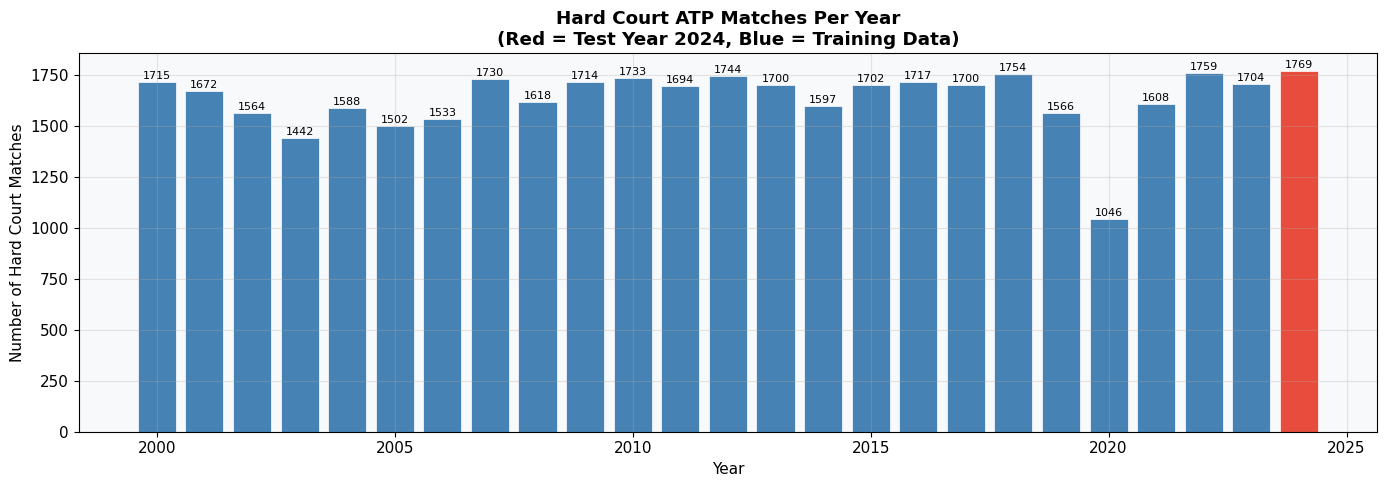

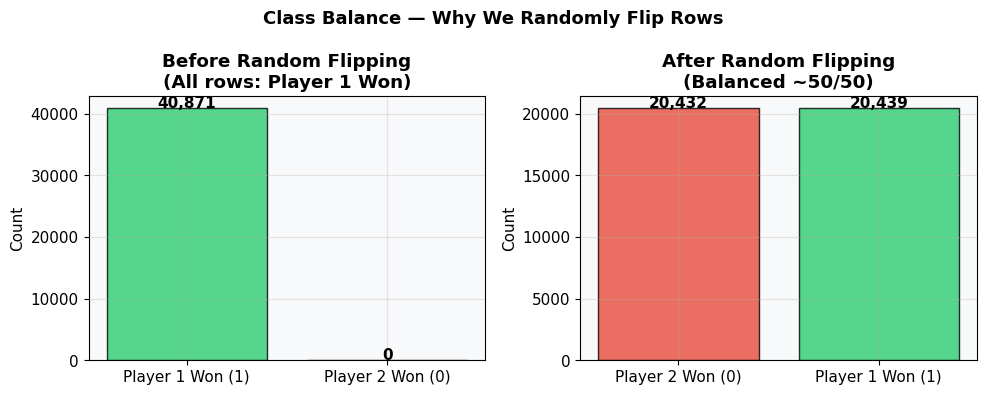

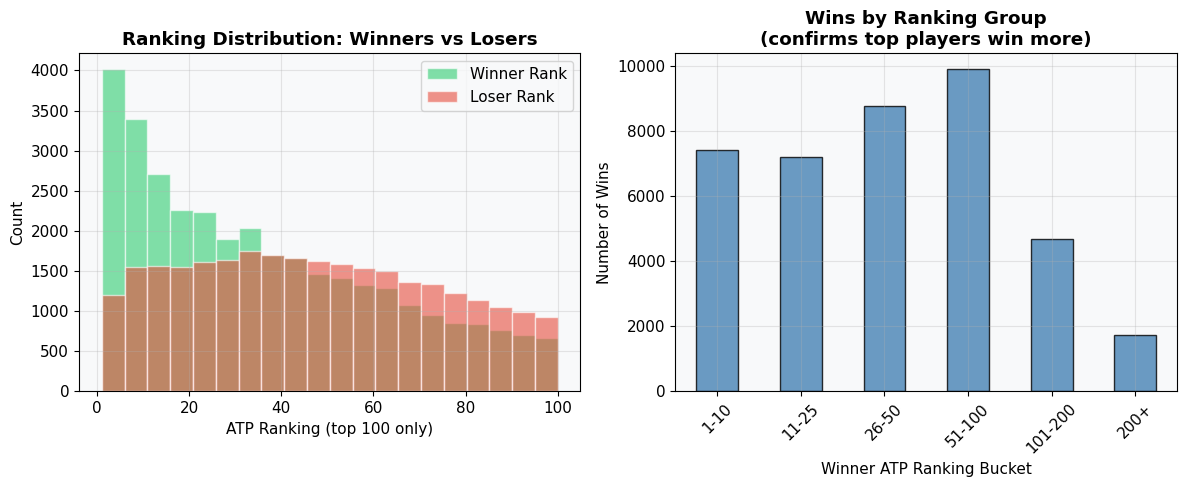

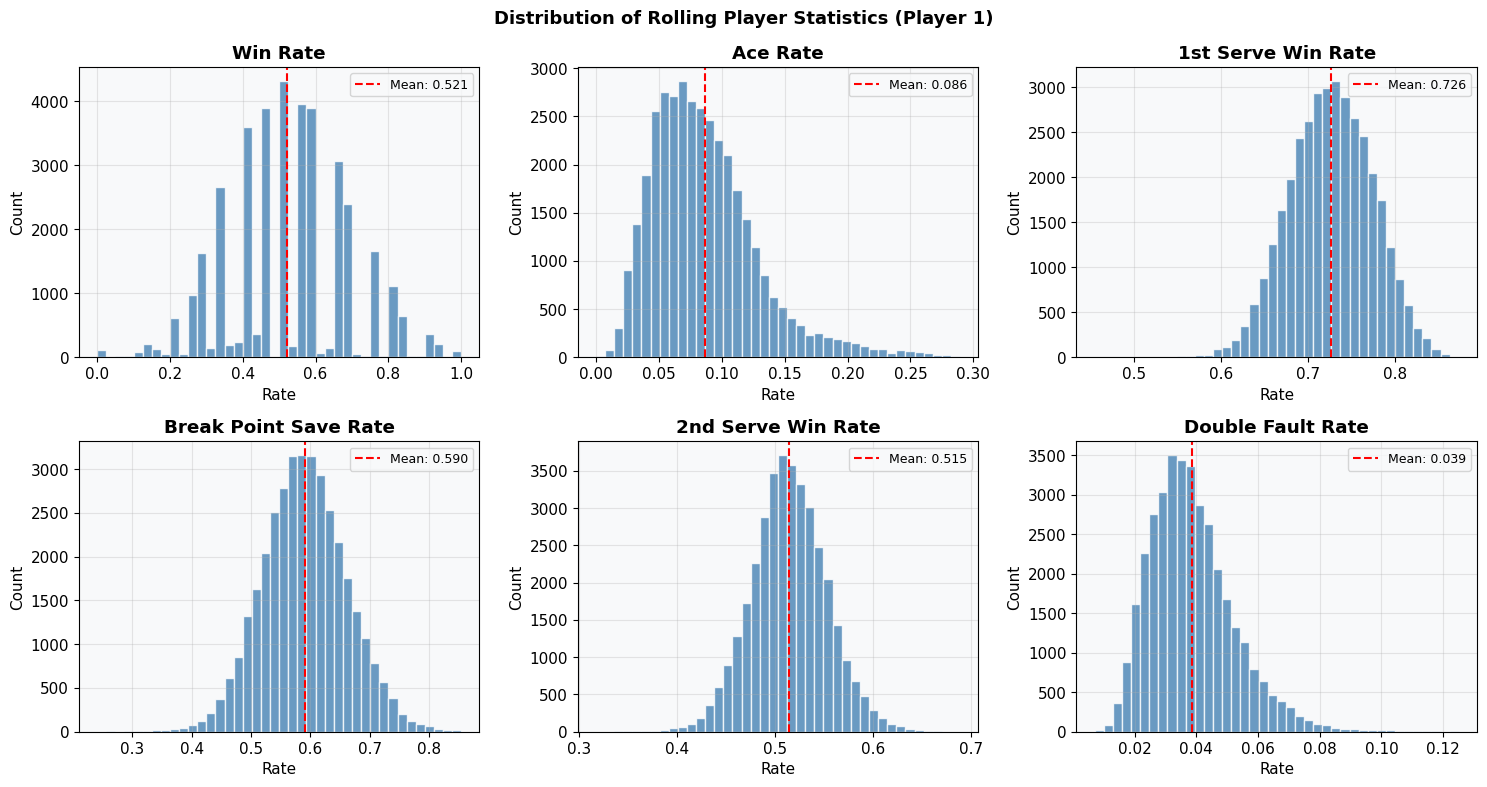

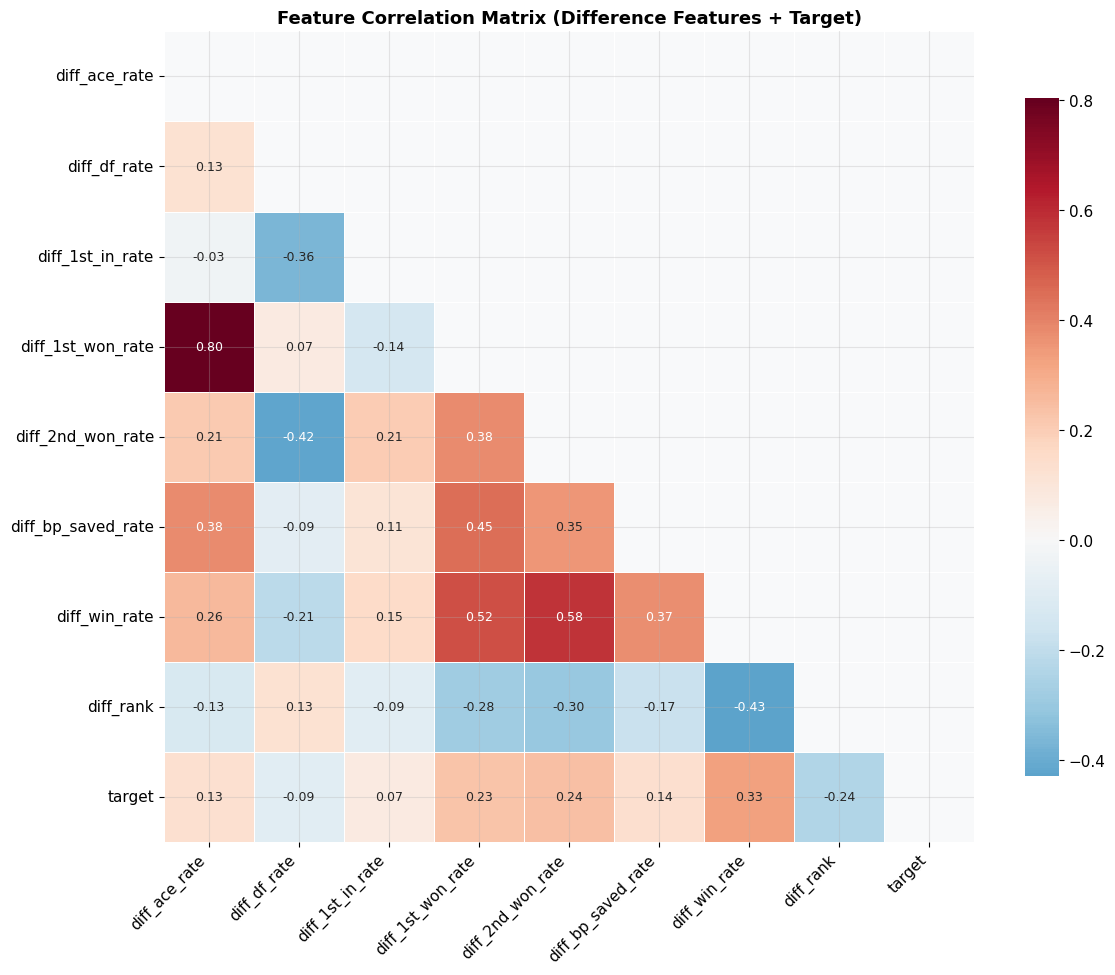

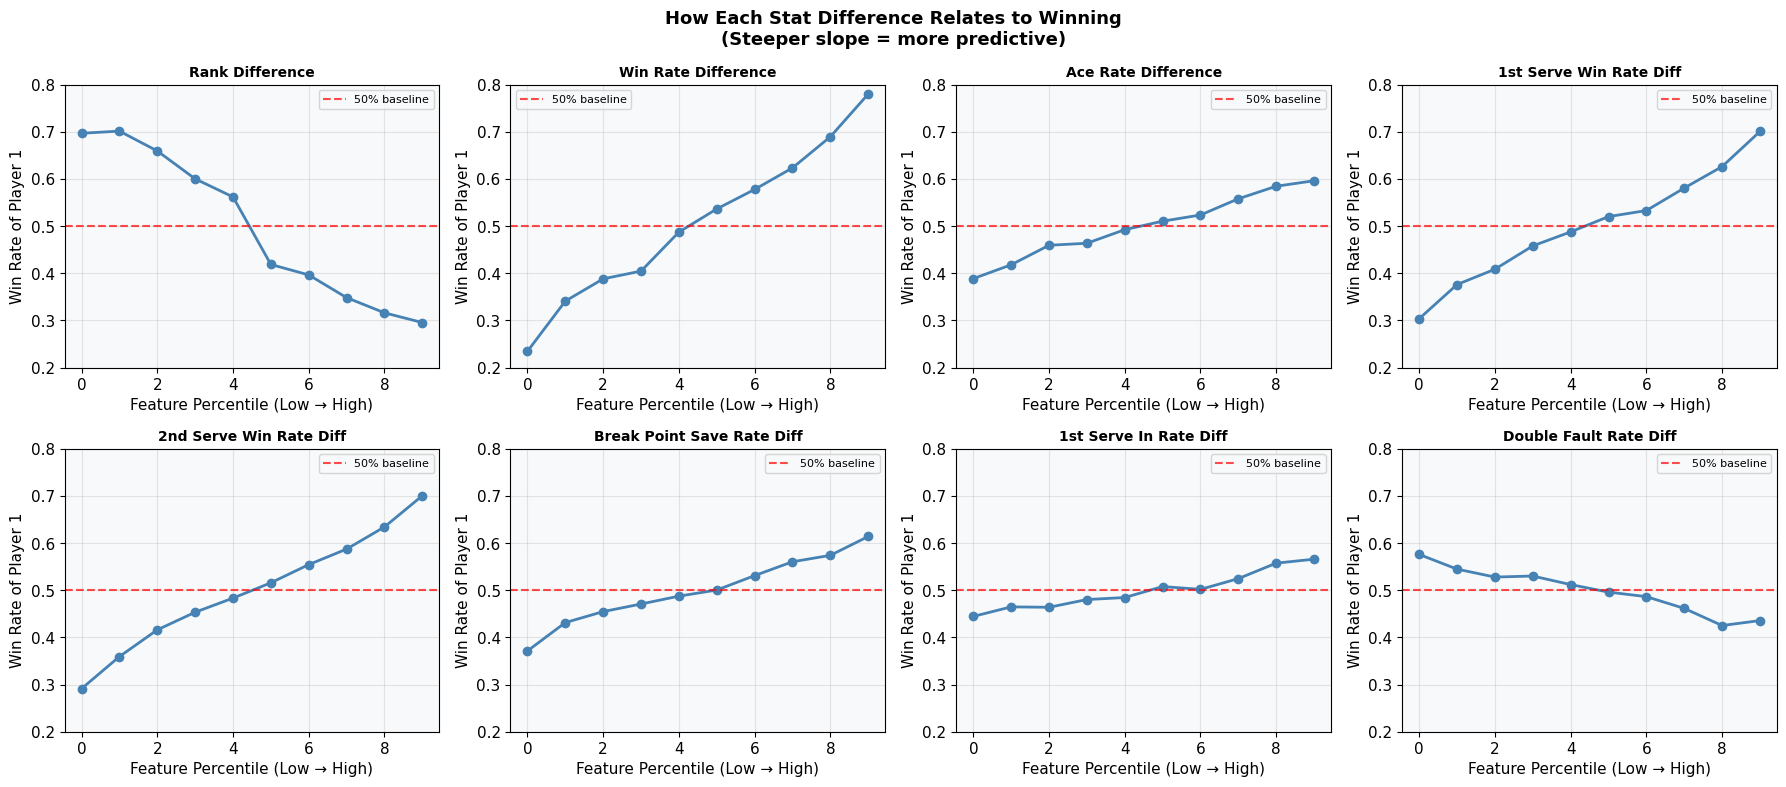

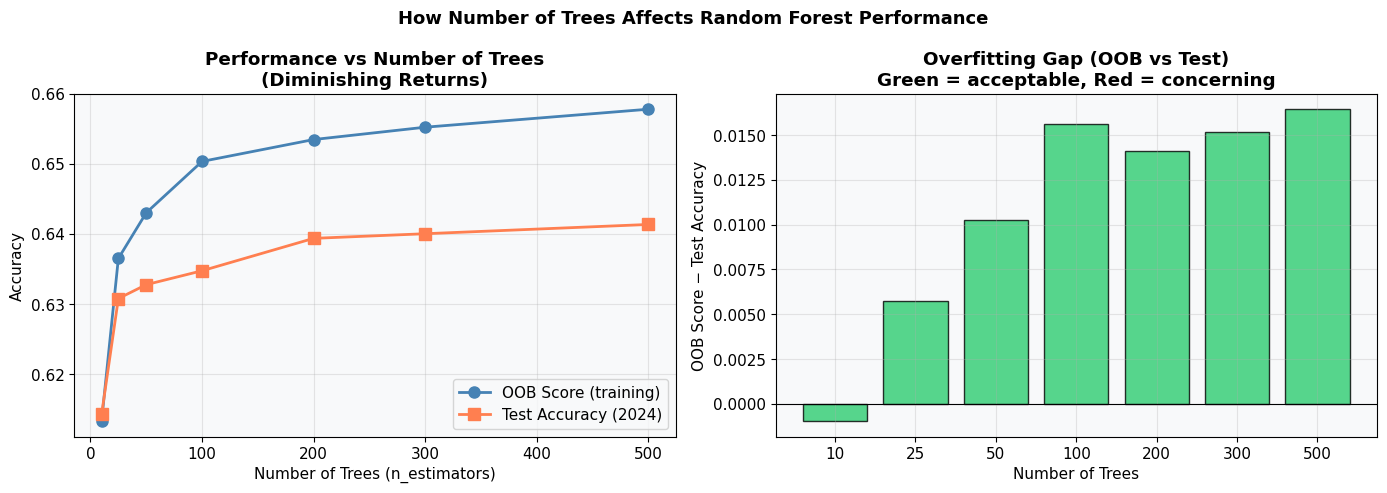

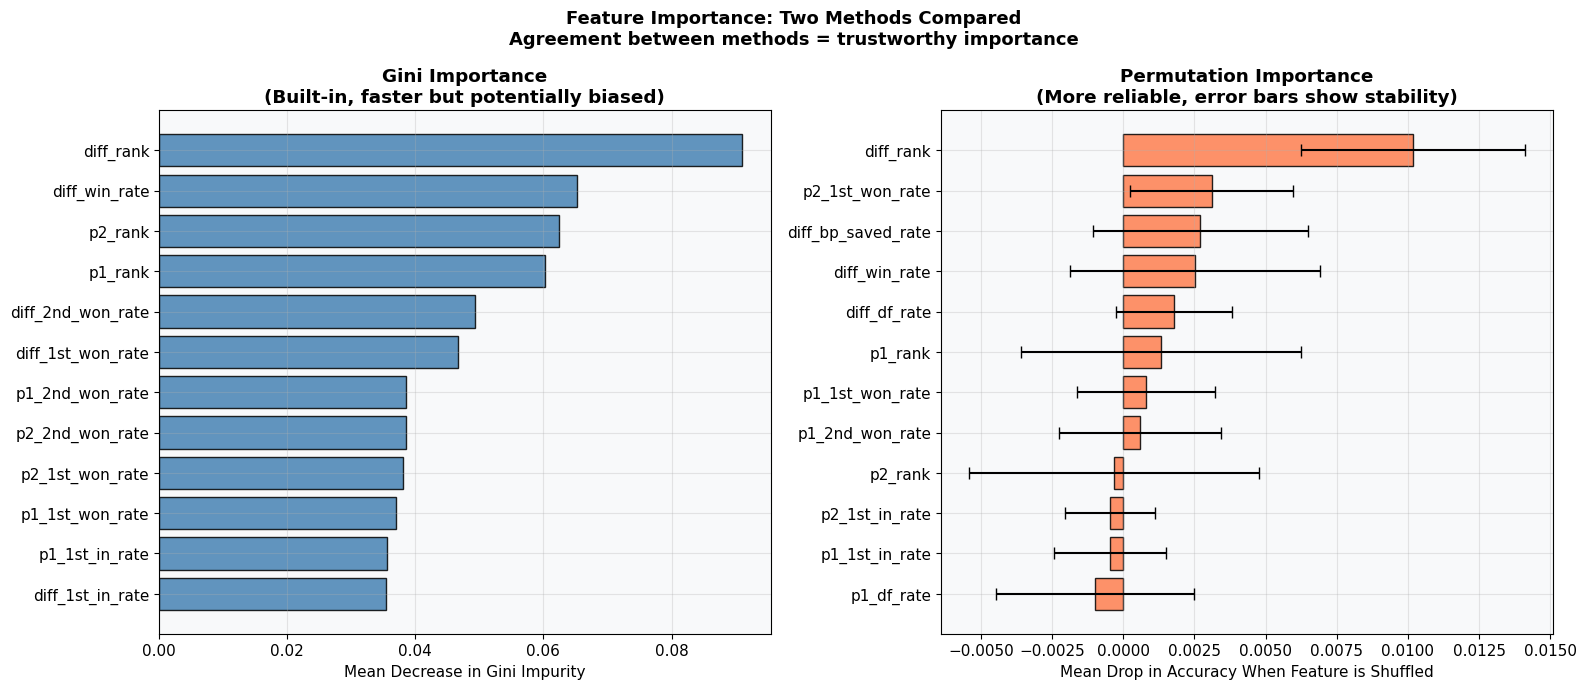

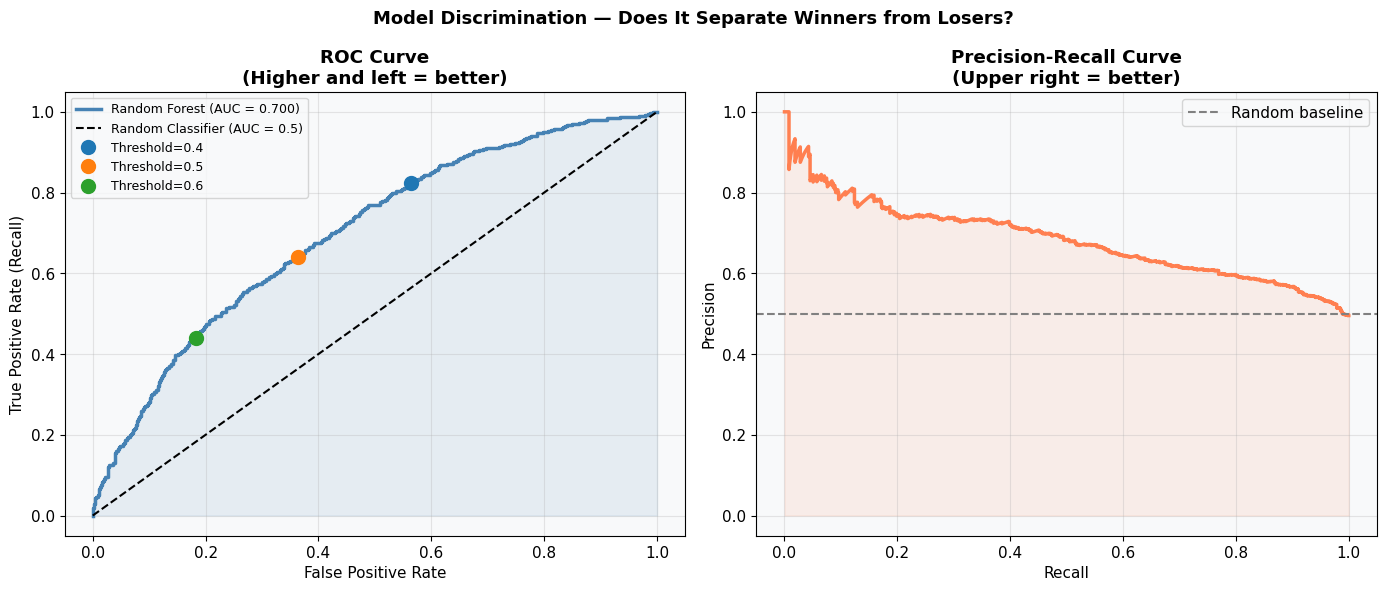

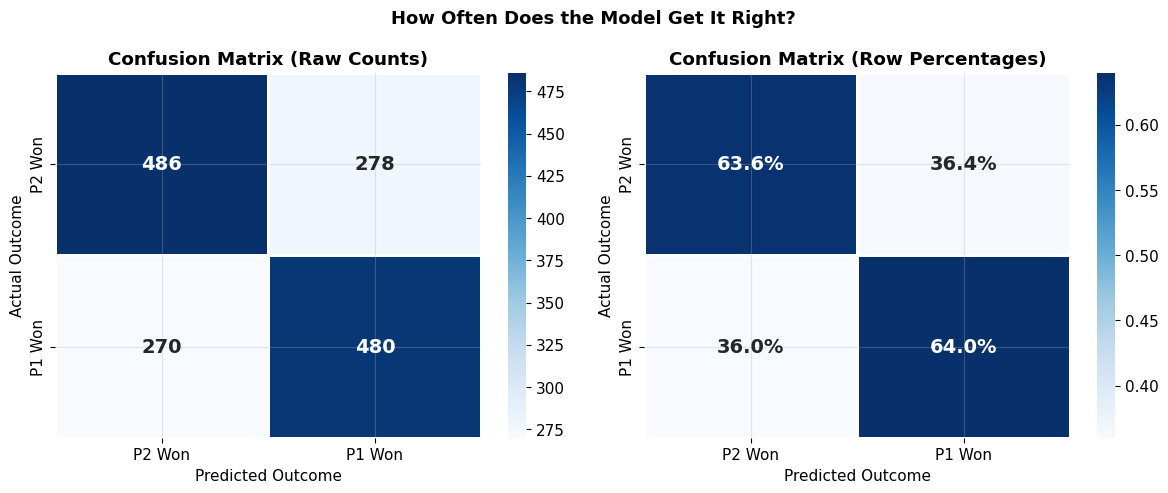

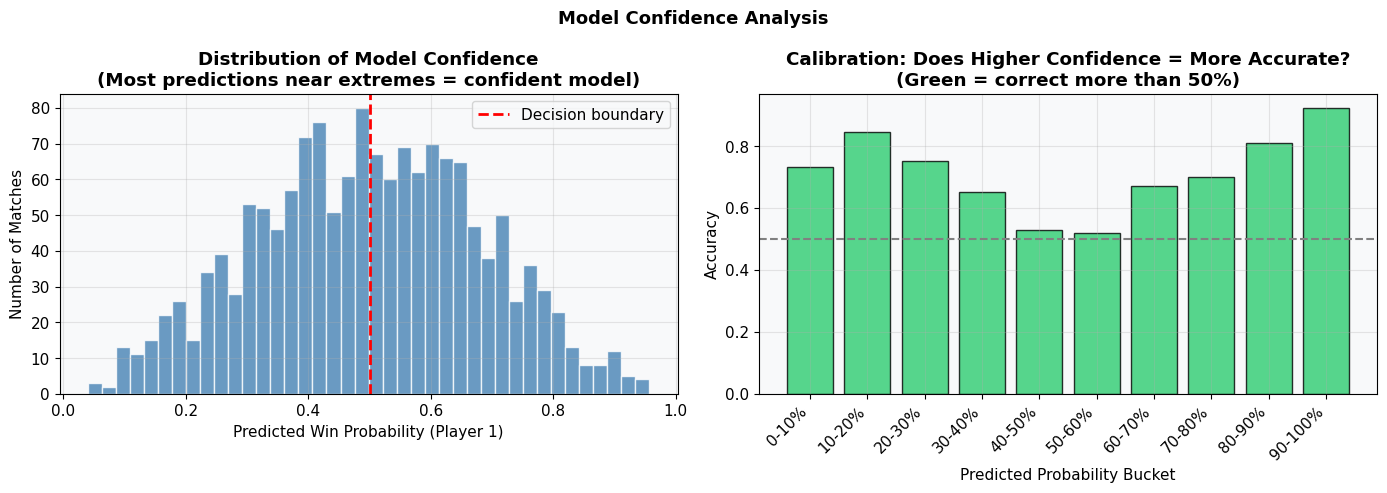

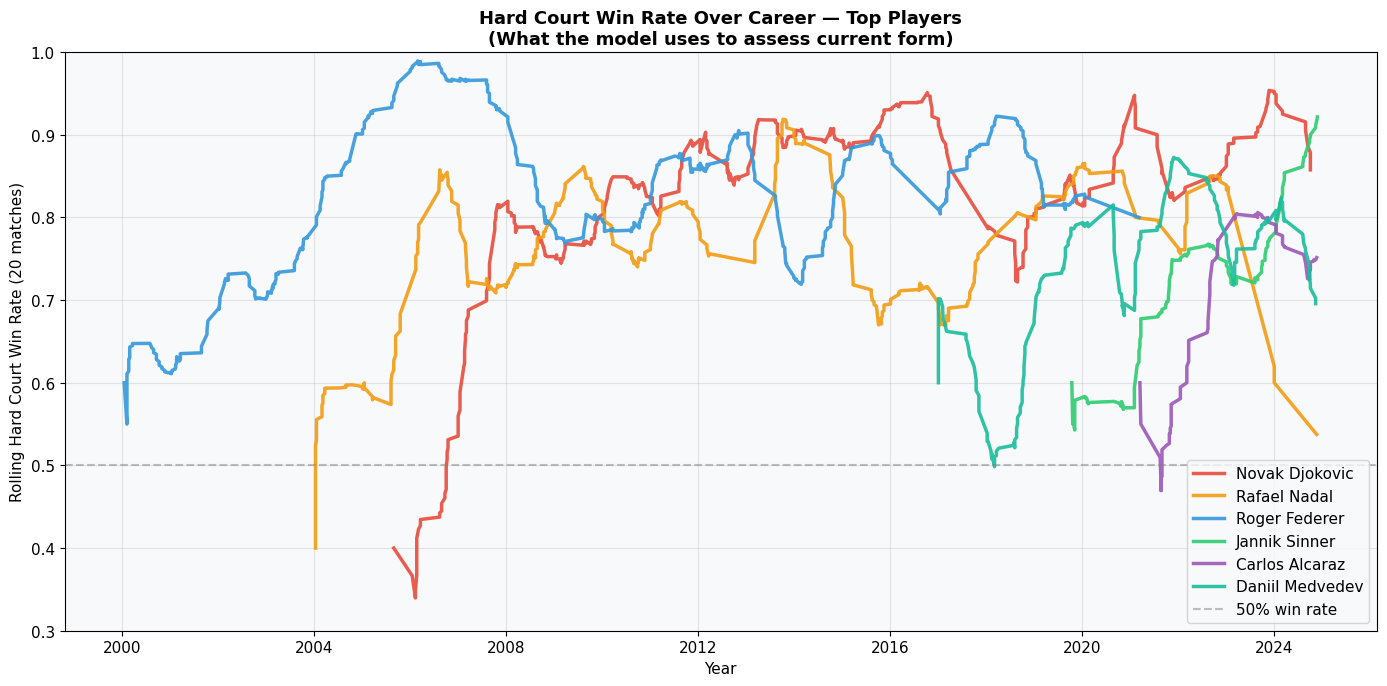

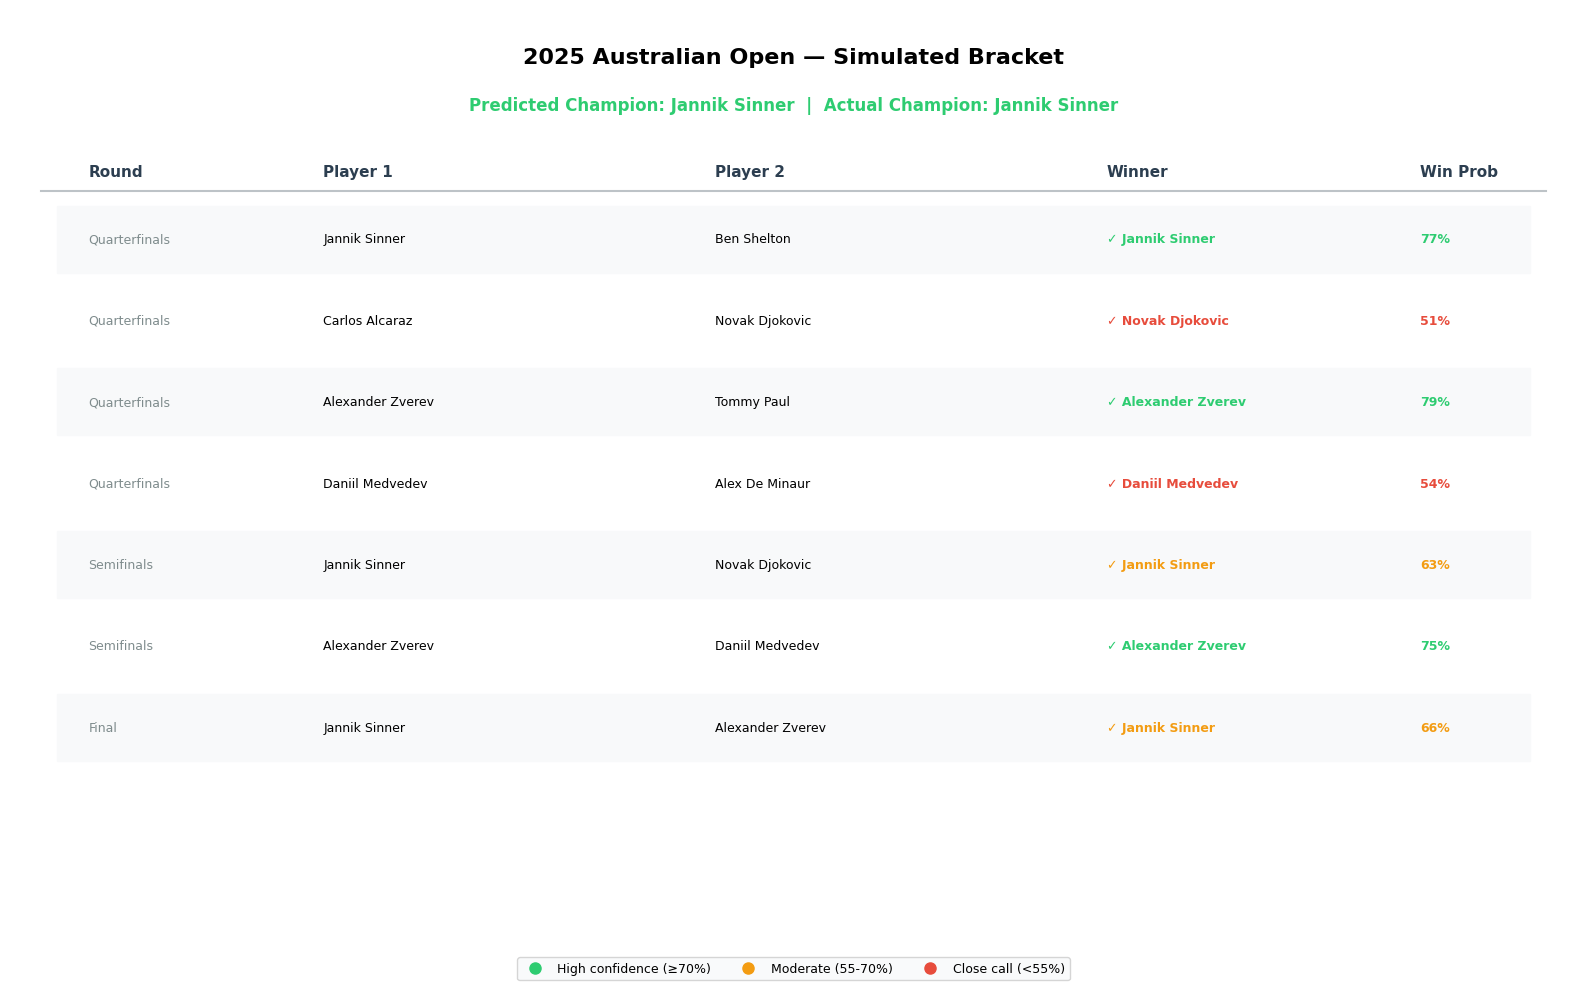

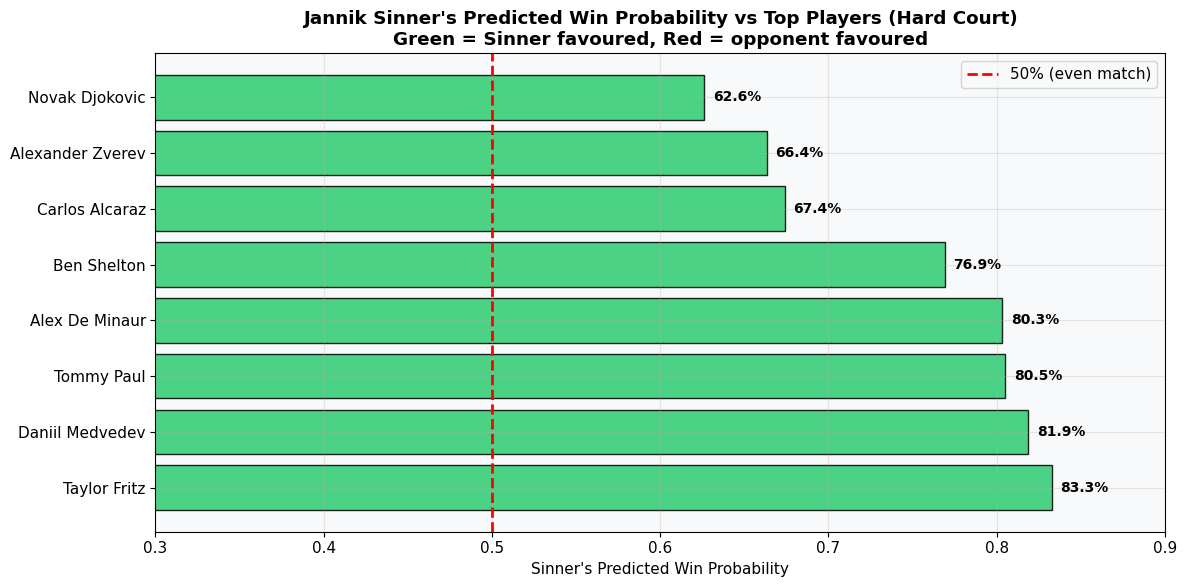

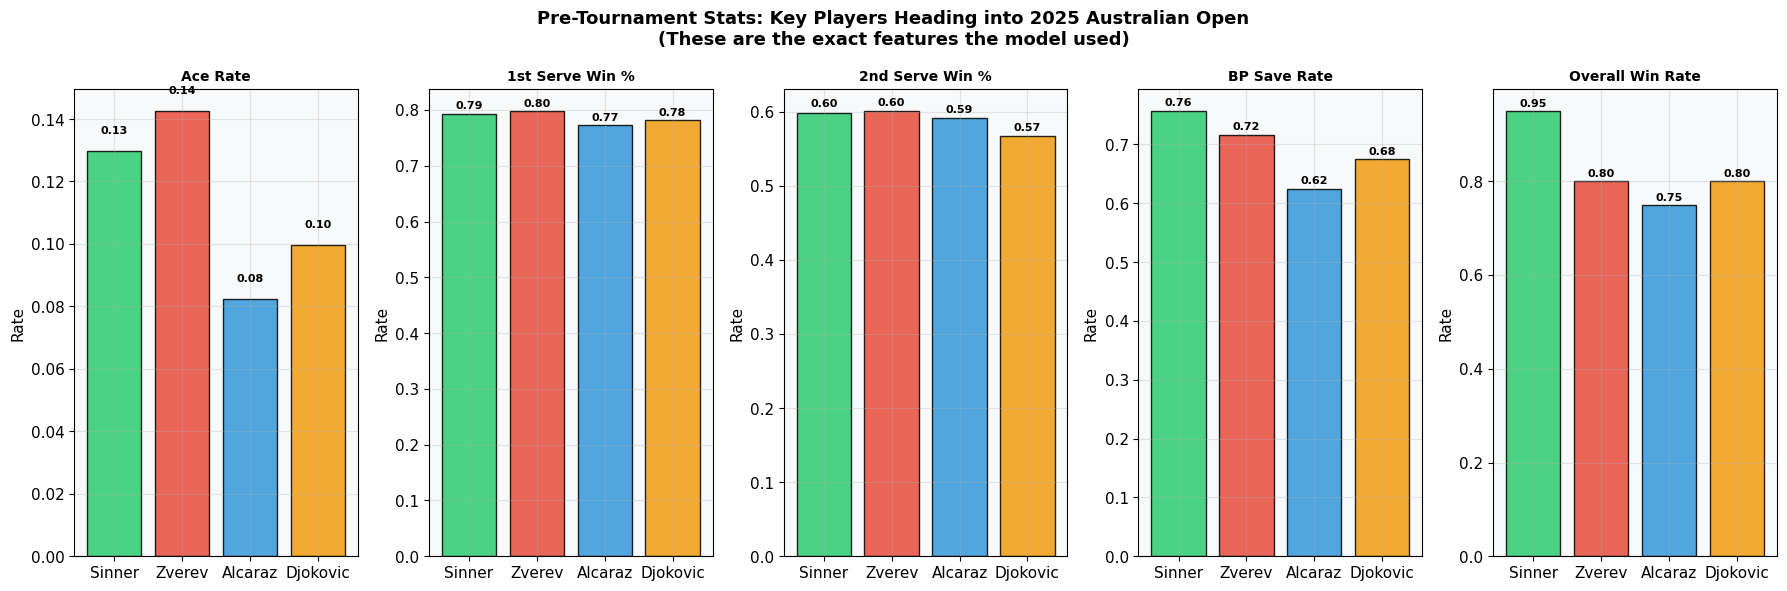


✅ All visualizations complete.
   Total plots generated: 15
   Predicted champion: Jannik Sinner
   Actual champion: Jannik Sinner
   Model result: ✅ CORRECT


In [ ]:
# ══════════════════════════════════════════════════════════════
# VISUALIZATION SECTION
# Run this after all the code above has been executed
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

# Set a clean global style for all plots
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11


# ══════════════════════════════════════════════════════════════
# VIZ 1: DATASET OVERVIEW — MATCHES PER YEAR ON HARD COURT
# ══════════════════════════════════════════════════════════════
# Shows how much data we have per year and gives a sense of
# the scale of the dataset we trained on.

plt.figure(figsize=(14, 5))
matches_per_year = df_hard.groupby(df_hard['tourney_date'].dt.year).size()
colors = ['#e74c3c' if y == 2024 else 'steelblue' for y in matches_per_year.index]
# Red bar for 2024 — our test year. Blue for all training years.

bars = plt.bar(matches_per_year.index, matches_per_year.values,
               color=colors, edgecolor='white', linewidth=0.5)
plt.xlabel('Year')
plt.ylabel('Number of Hard Court Matches')
plt.title('Hard Court ATP Matches Per Year\n(Red = Test Year 2024, Blue = Training Data)',
          fontweight='bold')

# Add value labels on top of each bar
for bar, val in zip(bars, matches_per_year.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 2: TARGET BALANCE — BEFORE AND AFTER FLIPPING
# ══════════════════════════════════════════════════════════════
# Confirms that our random flipping created a balanced dataset.
# A balanced target is important — imbalanced targets cause
# the model to be biased toward the majority class.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before flipping (all 1s — not useful but educational)
axes[0].bar(['Player 1 Won (1)', 'Player 2 Won (0)'],
            [len(match_features), 0],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[0].set_title('Before Random Flipping\n(All rows: Player 1 Won)', fontweight='bold')
axes[0].set_ylabel('Count')

# After flipping
target_counts = match_features['target'].value_counts().sort_index()
axes[1].bar(['Player 2 Won (0)', 'Player 1 Won (1)'],
            [target_counts.get(0, 0), target_counts.get(1, 0)],
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.8)
axes[1].set_title('After Random Flipping\n(Balanced ~50/50)', fontweight='bold')
axes[1].set_ylabel('Count')

for ax in axes:
    for patch in ax.patches:
        ax.text(patch.get_x() + patch.get_width()/2,
                patch.get_height() + 100,
                f'{int(patch.get_height()):,}',
                ha='center', fontweight='bold')

plt.suptitle('Class Balance — Why We Randomly Flip Rows', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 3: RANKING DISTRIBUTION OF WINNERS VS LOSERS
# ══════════════════════════════════════════════════════════════
# Higher ranked players (lower rank number) win more often.
# This sanity check confirms our data makes sense before modeling.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
winner_ranks = df_hard['winner_rank'].dropna()
loser_ranks = df_hard['loser_rank'].dropna()

plt.hist(winner_ranks[winner_ranks <= 100], bins=20, alpha=0.6,
         color='#2ecc71', label='Winner Rank', edgecolor='white')
plt.hist(loser_ranks[loser_ranks <= 100], bins=20, alpha=0.6,
         color='#e74c3c', label='Loser Rank', edgecolor='white')
plt.xlabel('ATP Ranking (top 100 only)')
plt.ylabel('Count')
plt.title('Ranking Distribution: Winners vs Losers', fontweight='bold')
plt.legend()

plt.subplot(1, 2, 2)
# Win rate by ranking bucket
df_hard['winner_rank_bucket'] = pd.cut(df_hard['winner_rank'],
                                        bins=[0,10,25,50,100,200,500],
                                        labels=['1-10','11-25','26-50','51-100','101-200','200+'])
win_rate_by_rank = df_hard.groupby('winner_rank_bucket', observed=True).size()
win_rate_by_rank.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.xticks(rotation=45)
plt.xlabel('Winner ATP Ranking Bucket')
plt.ylabel('Number of Wins')
plt.title('Wins by Ranking Group\n(confirms top players win more)', fontweight='bold')

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 4: STAT DISTRIBUTIONS — ROLLING FEATURES
# ══════════════════════════════════════════════════════════════
# Shows the distribution of each rolling stat feature across
# all matches. Helps spot outliers or data quality issues.

rolling_stat_cols = ['p1_win_rate', 'p1_ace_rate', 'p1_1st_won_rate',
                     'p1_bp_saved_rate', 'p1_2nd_won_rate', 'p1_df_rate']

labels = ['Win Rate', 'Ace Rate', '1st Serve Win Rate',
          'Break Point Save Rate', '2nd Serve Win Rate', 'Double Fault Rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col, label in zip(axes, rolling_stat_cols, labels):
    data = match_features[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Rate')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Rolling Player Statistics (Player 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 5: CORRELATION BETWEEN FEATURES
# ══════════════════════════════════════════════════════════════
# Shows which features are correlated with each other.
# Highly correlated features are redundant — they carry the
# same information. This is why feature selection matters.

diff_cols = [c for c in match_features.columns if c.startswith('diff_')]
corr_data = match_features[diff_cols + ['target']].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# mask the upper triangle — the matrix is symmetric so we only
# need to show the lower half to avoid redundancy

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',        # Red = positive correlation, Blue = negative
    center=0,             # White at zero
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Matrix (Difference Features + Target)',
          fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 6: DIFFERENCE FEATURES VS WIN PROBABILITY
# ══════════════════════════════════════════════════════════════
# For each difference feature, shows how the gap between
# players relates to the probability of winning.
# A steeper slope = more predictive feature.

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

diff_feature_labels = {
    'diff_rank': 'Rank Difference',
    'diff_win_rate': 'Win Rate Difference',
    'diff_ace_rate': 'Ace Rate Difference',
    'diff_1st_won_rate': '1st Serve Win Rate Diff',
    'diff_2nd_won_rate': '2nd Serve Win Rate Diff',
    'diff_bp_saved_rate': 'Break Point Save Rate Diff',
    'diff_1st_in_rate': '1st Serve In Rate Diff',
    'diff_df_rate': 'Double Fault Rate Diff',
}

plot_data = match_features[list(diff_feature_labels.keys()) + ['target']].dropna()

for ax, (col, label) in zip(axes, diff_feature_labels.items()):
    # Bin the difference feature into 10 buckets
    plot_data['bin'] = pd.qcut(plot_data[col], q=10, duplicates='drop')
    win_rate_by_bin = plot_data.groupby('bin', observed=True)['target'].mean()
    bin_centers = range(len(win_rate_by_bin))

    ax.plot(bin_centers, win_rate_by_bin.values, 'o-',
            color='steelblue', linewidth=2, markersize=6)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% baseline')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature Percentile (Low → High)')
    ax.set_ylabel('Win Rate of Player 1')
    ax.set_ylim(0.2, 0.8)
    ax.legend(fontsize=8)

plt.suptitle('How Each Stat Difference Relates to Winning\n(Steeper slope = more predictive)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 7: OVERFITTING — TRAINING VS TEST ACCURACY BY N_ESTIMATORS
# ══════════════════════════════════════════════════════════════
# Shows diminishing returns as you add more trees.
# Already computed in the code above — we just plot it here
# with more detail.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_estimator_range, oob_scores, 'o-', color='steelblue',
             label='OOB Score (training)', linewidth=2, markersize=8)
axes[0].plot(n_estimator_range, test_scores, 's-', color='coral',
             label='Test Accuracy (2024)', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Trees (n_estimators)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Performance vs Number of Trees\n(Diminishing Returns)',
                   fontweight='bold')
axes[0].legend()

# Gap between OOB and test score
gap = [oob - test for oob, test in zip(oob_scores, test_scores)]
axes[1].bar(range(len(n_estimator_range)), gap,
            color=['#e74c3c' if g > 0.02 else '#2ecc71' for g in gap],
            edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(n_estimator_range)))
axes[1].set_xticklabels(n_estimator_range)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('OOB Score − Test Accuracy')
axes[1].set_title('Overfitting Gap (OOB vs Test)\nGreen = acceptable, Red = concerning',
                   fontweight='bold')

plt.suptitle('How Number of Trees Affects Random Forest Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 8: FEATURE IMPORTANCE — GINI VS PERMUTATION SIDE BY SIDE
# ══════════════════════════════════════════════════════════════
# Comparing both importance methods reveals whether the built-in
# Gini importance is trustworthy or inflated for certain features.

top_n = 12
top_gini = importance_df.head(top_n).sort_values('Importance')
top_perm = perm_df.head(top_n).sort_values('Importance')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gini importance
axes[0].barh(top_gini['Feature'], top_gini['Importance'],
             color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Gini Importance\n(Built-in, faster but potentially biased)',
                   fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Gini Impurity')

# Permutation importance with error bars
axes[1].barh(top_perm['Feature'], top_perm['Importance'],
             xerr=top_perm['Std'],
             color='coral', edgecolor='black', alpha=0.85,
             error_kw={'ecolor': 'black', 'capsize': 4})
axes[1].set_title('Permutation Importance\n(More reliable, error bars show stability)',
                   fontweight='bold')
axes[1].set_xlabel('Mean Drop in Accuracy When Feature is Shuffled')

plt.suptitle('Feature Importance: Two Methods Compared\n'
             'Agreement between methods = trustworthy importance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 9: ROC CURVE WITH OPERATING POINTS
# ══════════════════════════════════════════════════════════════
# Shows model discrimination ability across all thresholds.
# We mark key operating points (0.4, 0.5, 0.6 thresholds)
# so you can see the precision-recall tradeoff visually.

from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='steelblue', lw=2.5,
             label=f'Random Forest (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')

# Mark specific threshold operating points
for threshold in [0.4, 0.5, 0.6]:
    idx = np.argmin(np.abs(roc_thresholds - threshold))
    axes[0].plot(fpr[idx], tpr[idx], 'o', markersize=10,
                label=f'Threshold={threshold}')

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve\n(Higher and left = better)', fontweight='bold')
axes[0].legend(fontsize=9)

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color='coral', lw=2.5)
axes[1].fill_between(recall, precision, alpha=0.1, color='coral')
axes[1].axhline(0.5, color='gray', linestyle='--', label='Random baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve\n(Upper right = better)', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Discrimination — Does It Separate Winners from Losers?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 10: CONFUSION MATRIX — WITH NORMALIZED VERSION
# ══════════════════════════════════════════════════════════════
# Two versions: raw counts and percentages.
# The normalized version is easier to interpret because it's
# not affected by class imbalance.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Divide each row by its sum to get row-wise percentages.
# Row = actual class. So each row sums to 100%.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['P2 Won', 'P1 Won'],
            yticklabels=['P2 Won', 'P1 Won'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')
axes[0].set_ylabel('Actual Outcome')
axes[0].set_xlabel('Predicted Outcome')

sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=['P2 Won', 'P1 Won'],
            yticklabels=['P2 Won', 'P1 Won'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix (Row Percentages)', fontweight='bold')
axes[1].set_ylabel('Actual Outcome')
axes[1].set_xlabel('Predicted Outcome')

plt.suptitle('How Often Does the Model Get It Right?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 11: PREDICTION CONFIDENCE DISTRIBUTION
# ══════════════════════════════════════════════════════════════
# Shows how confident the model is in its predictions.
# A good model should be very confident when it's right
# and less confident when it's wrong or predicting upsets.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of win probabilities
axes[0].hist(y_prob, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary')
axes[0].set_xlabel('Predicted Win Probability (Player 1)')
axes[0].set_ylabel('Number of Matches')
axes[0].set_title('Distribution of Model Confidence\n(Most predictions near extremes = confident model)',
                   fontweight='bold')
axes[0].legend()

# Confidence vs accuracy — does higher confidence mean more correct?
confidence_bins = pd.cut(y_prob, bins=np.arange(0, 1.05, 0.1))
results_df = pd.DataFrame({'prob': y_prob, 'correct': (y_pred == y_test).values})
accuracy_by_confidence = results_df.groupby(pd.cut(results_df['prob'],
                                                     bins=np.arange(0, 1.05, 0.1)))['correct'].mean()
bin_labels = [f'{int(b.left*100)}-{int(b.right*100)}%'
              for b in accuracy_by_confidence.index]

colors = ['#e74c3c' if a < 0.5 else '#2ecc71' for a in accuracy_by_confidence.values]
axes[1].bar(range(len(accuracy_by_confidence)), accuracy_by_confidence.values,
            color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Predicted Probability Bucket')
axes[1].set_title('Calibration: Does Higher Confidence = More Accurate?\n(Green = correct more than 50%)',
                   fontweight='bold')

plt.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 12: TOP PLAYERS — ROLLING WIN RATE OVER TIME
# ══════════════════════════════════════════════════════════════
# Shows the career trajectory of top players on hard courts.
# This is what the model is learning from — each player's
# evolving performance over time.

top_players = ['Novak Djokovic', 'Rafael Nadal', 'Roger Federer',
               'Jannik Sinner', 'Carlos Alcaraz', 'Daniil Medvedev']

plt.figure(figsize=(14, 7))
colors_players = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']

for player, color in zip(top_players, colors_players):
    player_data = player_history[
        (player_history['player'] == player) &
        (player_history['rolling_win_rate'].notna())
    ].copy()

    if len(player_data) < 10:
        continue

    # Smooth the rolling win rate with a further rolling average
    # to reduce noise in the career trajectory line
    player_data = player_data.set_index('date').sort_index()
    smoothed = player_data['rolling_win_rate'].rolling('365D').mean()
    # '365D' = rolling window of 365 days — one year smoothing

    plt.plot(smoothed.index, smoothed.values,
             color=color, linewidth=2.5, label=player, alpha=0.9)

plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% win rate')
plt.xlabel('Year')
plt.ylabel('Rolling Hard Court Win Rate (20 matches)')
plt.title('Hard Court Win Rate Over Career — Top Players\n'
          '(What the model uses to assess current form)',
          fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.ylim(0.3, 1.0)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 13: 2025 AO SIMULATION — BRACKET VISUALIZATION
# ══════════════════════════════════════════════════════════════
# Visual representation of our simulated bracket showing
# who advanced at each round and with what probability.

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('white')

# Color each match box by win probability
# Green = high confidence, Yellow = moderate, Red = close call
def prob_to_color(prob):
    if prob >= 0.70:
        return '#2ecc71'    # Green — confident prediction
    elif prob >= 0.55:
        return '#f39c12'    # Orange — moderate confidence
    else:
        return '#e74c3c'    # Red — close call / upset territory

# Draw the match log as a bracket table
ax.text(5, 9.5, '2025 Australian Open — Simulated Bracket',
        ha='center', va='center', fontsize=16, fontweight='bold')
ax.text(5, 9.0, f'Predicted Champion: {champion}  |  Actual Champion: Jannik Sinner',
        ha='center', va='center', fontsize=12,
        color='#2ecc71' if champion == 'Jannik Sinner' else '#e74c3c',
        fontweight='bold')

# Column headers
headers = ['Round', 'Player 1', 'Player 2', 'Winner', 'Win Prob']
col_positions = [0.5, 2.0, 4.5, 7.0, 9.0]
for header, x in zip(headers, col_positions):
    ax.text(x, 8.3, header, ha='left', va='center',
            fontsize=11, fontweight='bold', color='#2c3e50')

ax.axhline(8.1, color='#bdc3c7', linewidth=1.5, xmin=0.02, xmax=0.98)

# Draw each match as a row
for i, (_, row) in enumerate(match_log.iterrows()):
    y = 7.6 - i * 0.85
    if y < 0.5:
        break

    # Alternating row background
    if i % 2 == 0:
        rect = plt.Rectangle((0.3, y - 0.35), 9.4, 0.7,
                              color='#f8f9fa', zorder=0)
        ax.add_patch(rect)

    color = prob_to_color(row['win_probability'])

    ax.text(0.5, y, row['round'], ha='left', va='center', fontsize=9, color='#7f8c8d')
    ax.text(2.0, y, row['player1'], ha='left', va='center', fontsize=9)
    ax.text(4.5, y, row['player2'], ha='left', va='center', fontsize=9)

    # Winner in bold with confidence color
    ax.text(7.0, y, f"✓ {row['winner']}", ha='left', va='center',
            fontsize=9, fontweight='bold', color=color)
    ax.text(9.0, y, f"{row['win_probability']:.0%}", ha='left', va='center',
            fontsize=9, color=color, fontweight='bold')

# Legend for confidence colors
legend_y = 0.3
for label, color in [('High confidence (≥70%)', '#2ecc71'),
                      ('Moderate (55-70%)', '#f39c12'),
                      ('Close call (<55%)', '#e74c3c')]:
    ax.plot([], [], 'o', color=color, label=label, markersize=8)
ax.legend(loc='lower center', ncol=3, fontsize=9,
          bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 14: HEAD TO HEAD — SINNER VS TOP PLAYERS
# ══════════════════════════════════════════════════════════════
# Model's predicted win probability for Sinner against each
# top player. Shows clearly why the model picks him as champion.

opponents = ['Alexander Zverev', 'Carlos Alcaraz', 'Daniil Medvedev',
             'Novak Djokovic', 'Taylor Fritz', 'Ben Shelton',
             'Alex De Minaur', 'Tommy Paul']

sinner_probs = []
valid_opponents = []

for opponent in opponents:
    _, prob = predict_match('Jannik Sinner', opponent,
                             player_history, rf, feature_cols)
    # We want Sinner's probability regardless of which side he's on
    stats_s = get_player_stats('Jannik Sinner', player_history)
    stats_o = get_player_stats(opponent, player_history)
    if stats_s and stats_o:
        sinner_probs.append(prob)
        valid_opponents.append(opponent)

sorted_pairs = sorted(zip(sinner_probs, valid_opponents), reverse=True)
sinner_probs_sorted, opponents_sorted = zip(*sorted_pairs) if sorted_pairs else ([], [])

plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if p >= 0.60 else '#f39c12' if p >= 0.50 else '#e74c3c'
          for p in sinner_probs_sorted]

bars = plt.barh(opponents_sorted, sinner_probs_sorted,
                color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='50% (even match)')
plt.xlabel("Sinner's Predicted Win Probability")
plt.title("Jannik Sinner's Predicted Win Probability vs Top Players (Hard Court)\n"
          "Green = Sinner favoured, Red = opponent favoured",
          fontweight='bold')

for bar, prob in zip(bars, sinner_probs_sorted):
    plt.text(prob + 0.005, bar.get_y() + bar.get_height()/2,
             f'{prob:.1%}', va='center', fontweight='bold', fontsize=10)

plt.xlim(0.3, 0.9)
plt.legend()
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# VIZ 15: ROLLING SERVE STATS — KEY PLAYERS BEFORE 2025 AO
# ══════════════════════════════════════════════════════════════
# Bar chart comparing finalists' serve stats heading into
# the 2025 Australian Open — exactly what the model used.

key_players = ['Jannik Sinner', 'Alexander Zverev',
               'Carlos Alcaraz', 'Novak Djokovic']

stat_labels = {
    'rolling_ace_rate': 'Ace Rate',
    'rolling_1st_won_rate': '1st Serve Win %',
    'rolling_2nd_won_rate': '2nd Serve Win %',
    'rolling_bp_saved_rate': 'BP Save Rate',
    'rolling_win_rate': 'Overall Win Rate'
}

player_stat_values = {}
for player in key_players:
    stats = get_player_stats(player, player_history)
    if stats:
        player_stat_values[player] = stats

fig, axes = plt.subplots(1, len(stat_labels), figsize=(18, 6))
bar_width = 0.18
player_colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for ax, (stat_key, stat_label) in zip(axes, stat_labels.items()):
    stat_map = {
        'rolling_ace_rate': 'ace_rate',
        'rolling_1st_won_rate': '1st_won_rate',
        'rolling_2nd_won_rate': '2nd_won_rate',
        'rolling_bp_saved_rate': 'bp_saved_rate',
        'rolling_win_rate': 'win_rate'
    }
    inner_key = stat_map[stat_key]

    values = []
    names = []
    for player in key_players:
        if player in player_stat_values:
            val = player_stat_values[player].get(inner_key, 0)
            if val and not np.isnan(val):
                values.append(val)
                names.append(player.split()[-1])   # Last name only for space

    bars = ax.bar(names, values, color=player_colors[:len(names)],
                  edgecolor='black', alpha=0.85)
    ax.set_title(stat_label, fontweight='bold', fontsize=10)
    ax.set_ylabel('Rate')

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Pre-Tournament Stats: Key Players Heading into 2025 Australian Open\n'
             '(These are the exact features the model used)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n.  All visualizations complete.")
print(f"   Total plots generated: 15")
print(f"   Predicted champion: {champion}")
print(f"   Actual champion: Jannik Sinner")
print(f"   Model result: {' CORRECT' if champion == 'Jannik Sinner' else '❌ INCORRECT — but check the match log for where it went wrong'}")

Conclusion
We built a Random Forest model trained on 25 years of ATP hard court match data and simulated the 2025 Australian Open bracket to verify our predictions against real results.
The core lesson of Random Forests is that instability is fixable through diversity. A single decision tree is powerful but fragile — change a few training examples and you get a completely different tree. Random Forest fixes this by training hundreds of trees on different random subsets of data and features, then averaging their votes. The individual trees remain imperfect but their errors cancel out, producing a model that is far more stable and generalisable than any single tree could be.
The two innovations that make it work — bootstrap sampling and feature randomness — both serve the same mathematical goal: reducing the correlation between trees. The lower the correlation, the more individual errors cancel out when you average. This is the bias-variance decomposition made practical.
The project also introduced a concept more important than any model parameter: time-based splitting. In sports, finance, or any domain where data has a time dimension, randomly splitting your data leaks future information into training. You must always train on the past and test on a future period that the model never saw. This is the difference between a model that looks good in a notebook and one that would actually work in the real world.